# 🏆 Revenue Optimization System
## Demand Forecasting · Pricing Intelligence · Profit Simulation

---

| | |
|---|---|
| **Domain** | Retail / E-Commerce |
| **Dataset** | 2,800 transactions · 5 product categories · 50 stores · FY2025 |
| **Objective** | Optimize pricing and discount strategies to maximize revenue and profit |
| **Stack** | Python · Pandas · Scikit-learn · XGBoost · SciPy · Matplotlib |

> **Problem Context:** Discounting is often applied heuristically, leading to margin erosion. This system quantifies demand response to price changes and identifies scenarios where discounts drive incremental profit versus destroy value.

---

## 📋 Table of Contents
1. [Business Understanding & Data Overview](#phase1)
2. [Data Cleaning & Feature Engineering](#phase2)
3. [Exploratory Data Analysis](#phase3)
4. [Demand Forecasting](#phase4)
5. [Pricing Intelligence & Elasticity](#phase5)
6. [Discount & Profit Analysis](#phase6)
7. [Sensitivity Analysis](#phase7)
8. [Simulation Engine](#phase8)
9. [Model Assumptions & Limitations](#phase9)
10. [Final Recommendations & Priority Actions](#phase10)


## ⚙️ Setup & Environment Initialization

This section initializes the analytical environment required for the project.

It includes:
- Importing core libraries for data manipulation, modeling, and visualization  
- Configuring display settings for better readability  
- Setting global parameters for reproducibility and consistency  

All dependencies used in this project are listed in the `requirements.txt` file to ensure environment portability.

In [1]:
# ================================
# ⚙️ Environment Setup
# ================================

# ---- Core Libraries ----
import os
import warnings
import numpy as np
import pandas as pd

# ---- Visualization ----
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---- Statistical Analysis ----
from scipy import stats

# ---- Machine Learning ----
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ---- Configuration ----
warnings.filterwarnings('ignore')  # suppress non-critical warnings for cleaner output

RANDOM_STATE = 42  # ensures reproducibility
np.random.seed(RANDOM_STATE)

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

# ---- Directory Setup ----
PLOT_DIR = '../outputs/plots/'
os.makedirs(PLOT_DIR, exist_ok=True)

RESULT_DIR = '../outputs/results/'
os.makedirs(PLOT_DIR, exist_ok=True)

# ---- Visualization Theme ----
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3248',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#2e3248',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#2e3248',
})

PALETTE = ['#7c83fd', '#00d9c0', '#ff6b6b', '#ffc75f', '#a29bfe', '#fd79a8', '#55efc4']

# ---- Business Assumptions ----
# Approximate category-level gross margins (used for profit simulation)
MARGIN = {
    'Electronics': 0.25,
    'Clothing': 0.50,
    'Grocery': 0.20,
    'Home': 0.40,
    'Personal Care': 0.45,
}

print("✅ Environment setup complete.")

✅ Environment setup complete.


---
<a id='phase1'></a>
## Phase 1 — Business Understanding & Data Overview

**Objective:** Establish a clear mapping between raw data fields and business metrics to ensure all downstream analysis aligns with revenue and profitability decisions.

This phase focuses on:
- Interpreting each variable in a business context (e.g., pricing, demand, discounting)
- Identifying key drivers of revenue and profit
- Validating data structure, granularity, and time coverage

A strong understanding at this stage ensures that modeling and insights remain aligned with real-world pricing and demand dynamics.

In [2]:
df_raw = pd.read_csv('../data/retail_store_sales_promotions_demand.csv')

print("━" * 60)
print("  DATASET SNAPSHOT")
print("━" * 60)
print(f"  Rows            : {df_raw.shape[0]:,}")
print(f"  Columns         : {df_raw.shape[1]}")
print(f"  Date Range      : {df_raw['date'].min()}  →  {df_raw['date'].max()}")
print(f"  Categories      : {sorted(df_raw['category'].unique())}")
print(f"  Unique Stores   : {df_raw['store_id'].nunique()}")
print(f"  Unique Products : {df_raw['product_id'].nunique()}")
print(f"  Missing Values  : {df_raw.isnull().sum().sum()}")
print()
df_raw.head(8)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATASET SNAPSHOT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rows            : 2,800
  Columns         : 10
  Date Range      : 01-01-2025  →  31-12-2025
  Categories      : ['Clothing', 'Electronics', 'Grocery', 'Home', 'Personal Care']
  Unique Stores   : 50
  Unique Products : 947
  Missing Values  : 0



,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week
0,12,1823,19-09-2025,Home,1902,No,0,17,251,Friday
1,6,1551,21-12-2025,Grocery,2629,Yes,0,14,248,Wednesday
2,40,1015,27-09-2025,Grocery,2488,No,0,25,251,Saturday
3,50,1475,16-06-2025,Home,293,Yes,5,7,470,Tuesday
4,32,1004,05-12-2025,Grocery,2470,Yes,20,37,139,Saturday
5,46,1260,10-06-2025,Electronics,1923,No,0,10,228,Friday
6,26,1110,28-05-2025,Home,2150,No,0,6,35,Monday
7,4,1481,11-07-2025,Home,323,Yes,30,19,20,Tuesday


In [3]:
# Business concept mapping
mapping = {
    'date'             : ('📅 Time dimension',        'Forecasting & trend analysis'),
    'store_id'         : ('🏪 Store ID',              'Store-level segmentation'),
    'product_id'       : ('📦 Product ID',            'SKU-level pricing decisions'),
    'category'         : ('🏷️ Category',              'Category strategy design'),
    'price'            : ('💰 Selling Price (₹)',     'Primary pricing lever'),
    'promotion_active' : ('📢 Promotion Flag',        'Promotion effectiveness'),
    'discount_percent' : ('🔖 Discount % (0–30)',     'Margin sensitivity driver'),
    'units_sold'       : ('📊 Units Sold (Demand)',   'Forecasting target variable'),
    'inventory_level'  : ('📦 Inventory Level',       'Supply constraint'),
    'day_of_week'      : ('📆 Day of Week',           'Seasonality pattern'),
}

print(f"{'Column':<22} {'Business Name':<32} {'Role'}")
print("─" * 80)

for col, (name, role) in mapping.items():
    print(f"  {col:<20} {name:<32} {role}")

print()
print("  DERIVED KPIs (Phase 2):")
print("  revenue    = effective_price × units_sold")
print("  cost       = effective_price × (1 − margin) × units_sold")
print("  profit     = revenue − cost")
print("  effective_price = price × (1 − discount_percent / 100)")

Column                 Business Name                    Role
────────────────────────────────────────────────────────────────────────────────
  date                 📅 Time dimension                 Forecasting & trend analysis
  store_id             🏪 Store ID                       Store-level segmentation
  product_id           📦 Product ID                     SKU-level pricing decisions
  category             🏷️ Category                      Category strategy design
  price                💰 Selling Price (₹)              Primary pricing lever
  promotion_active     📢 Promotion Flag                 Promotion effectiveness
  discount_percent     🔖 Discount % (0–30)              Margin sensitivity driver
  units_sold           📊 Units Sold (Demand)            Forecasting target variable
  inventory_level      📦 Inventory Level                Supply constraint
  day_of_week          📆 Day of Week                    Seasonality pattern

  DERIVED KPIs (Phase 2):
  revenue    = effective_p

---
<a id='phase2'></a>
## Phase 2 — Data Cleaning & Feature Engineering

**Objective:** Transform raw transactional data into a structured dataset with validated metrics and engineered features required for demand modeling, pricing analysis, and profit simulation.

In [4]:
df = df_raw.copy()

# ── Date features ──────────────────────────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True, errors='coerce')
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['quarter']    = df['date'].dt.quarter
df['week'] = df['date'].dt.isocalendar().week.astype('Int64')
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# ── Pricing features ───────────────────────────────────────────────────────────
df['eff_price']    = df['price'] * (1 - df['discount_percent'] / 100)
df['discount_amt'] = df['price'] - df['eff_price']

# ── Revenue, Cost, Profit ──────────────────────────────────────────────────────
df['revenue']      = df['eff_price'] * df['units_sold']
df['gross_margin'] = df['category'].map(MARGIN)

# Validate margin mapping (important)
if df['gross_margin'].isnull().any():
    raise ValueError("Missing margin mapping for some categories")

df['cost']   = df['eff_price'] * (1 - df['gross_margin']) * df['units_sold']
df['profit'] = df['revenue'] - df['cost']

# Safe margin calculation
df['profit_margin_pct'] = np.where(
    df['revenue'] > 0,
    (df['profit'] / df['revenue']) * 100,
    0
).round(2)

# ── Price bands ────────────────────────────────────────────────────────────────
df['price_band'] = pd.cut(
    df['price'],
    bins=[0, 250, 750, 1500, 3000],
    labels=['Budget', 'Mid-Range', 'Premium', 'Luxury']
)

# ── Discount tiers ─────────────────────────────────────────────────────────────
df['discount_tier'] = pd.cut(
    df['discount_percent'],
    bins=[0, 10, 20, 30],
    labels=['Low (1–10%)', 'Medium (11–20%)', 'High (21–30%)'],
    include_lowest=True
)

df['discount_tier'] = df['discount_tier'].cat.add_categories(['None (0%)'])

# Add explicit "No Discount" category
df.loc[df['discount_percent'] == 0, 'discount_tier'] = 'None (0%)'

print("Feature Engineering Complete ✅")
print(f"  Columns before : {df_raw.shape[1]}")
print(f"  Columns after  : {df.shape[1]}  (+{df.shape[1]-df_raw.shape[1]} engineered)")
print()

print("━" * 50)
print("  PORTFOLIO-LEVEL KPIs")
print("━" * 50)

print(f"  Total Revenue  : ₹ {df['revenue'].sum():>15,.0f}")
print(f"  Total Cost     : ₹ {df['cost'].sum():>15,.0f}")
print(f"  Total Profit   : ₹ {df['profit'].sum():>15,.0f}")
print(f"  Blended Margin : {df['profit'].sum()/df['revenue'].sum()*100:.1f}%")
print(f"  Avg Price      : ₹ {df['price'].mean():,.0f}")
print(f"  Avg Units/Txn  : {df['units_sold'].mean():.1f}")

Feature Engineering Complete ✅
  Columns before : 10
  Columns after  : 25  (+15 engineered)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PORTFOLIO-LEVEL KPIs
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Revenue  : ₹     102,868,719
  Total Cost     : ₹      65,832,161
  Total Profit   : ₹      37,036,558
  Blended Margin : 36.0%
  Avg Price      : ₹ 1,519
  Avg Units/Txn  : 26.3


---
<a id='phase3'></a>
## Phase 3 — Exploratory Data Analysis

**Objective:** Analyze demand, pricing, and profitability patterns to identify key drivers of revenue and inform subsequent modeling and pricing strategies.

The goal is to uncover actionable insights that guide forecasting, elasticity modeling, and pricing decisions.

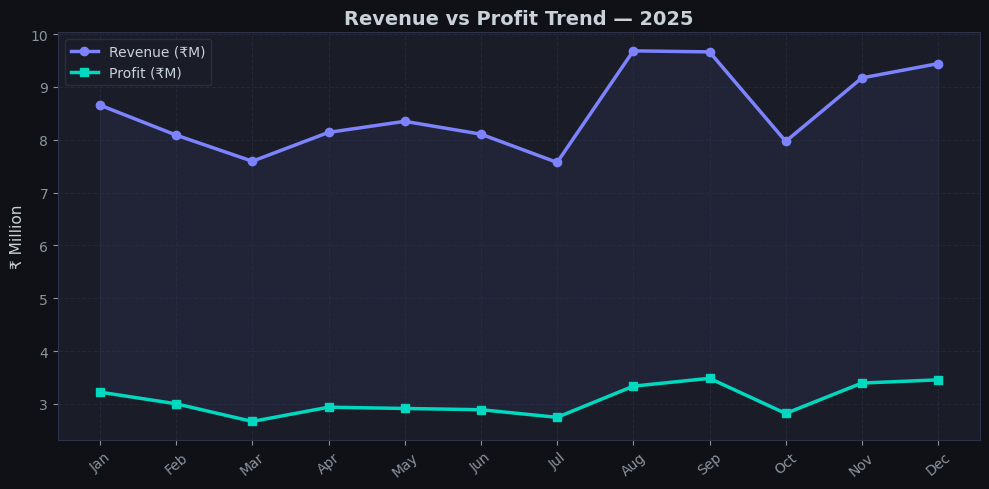

In [5]:
# ── 3.1 Revenue vs Profit (Combined Trend) ─────────────────────────────────────────
monthly = (df.groupby(['month', 'month_name'])[['revenue', 'profit']]
             .sum()
             .reset_index()
             .sort_values('month'))

x = range(len(monthly))

fig, ax = plt.subplots(figsize=(10, 5))

# Revenue
ax.plot(x, monthly['revenue']/1e6, marker='o',
        color=PALETTE[0], linewidth=2.5, label='Revenue (₹M)')

# Profit
ax.plot(x, monthly['profit']/1e6, marker='s',
        color=PALETTE[1], linewidth=2.5, label='Profit (₹M)')

# Fill area between for visual divergence
ax.fill_between(
    x,
    monthly['revenue']/1e6,
    monthly['profit']/1e6,
    where=(monthly['revenue'] >= monthly['profit']),
    color=PALETTE[0],
    alpha=0.08
)

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(monthly['month_name'], rotation=40)
ax.set_ylabel('₹ Million')
ax.set_title('Revenue vs Profit Trend — 2025', fontsize=14, fontweight='bold')

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'revenue_vs_profit.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

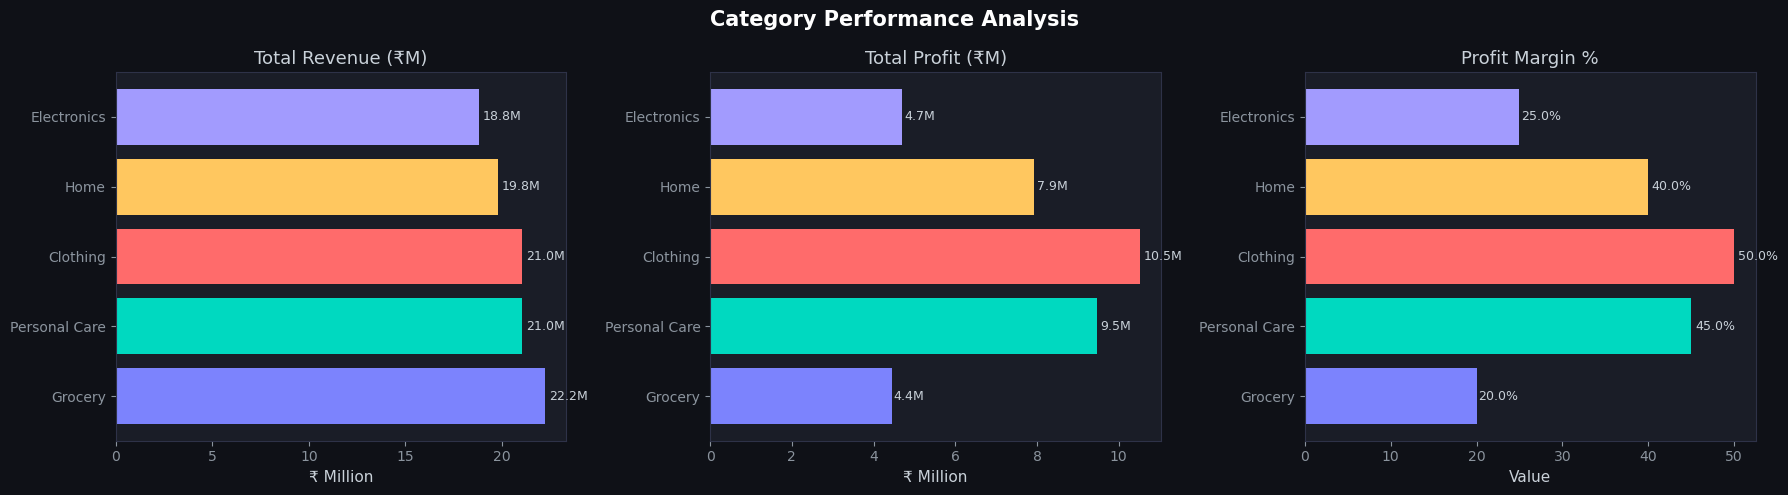

Category Performance Summary:
     category  total_revenue  total_profit  margin_pct  avg_price  txn_count
      Grocery  22,223,279.55  4,444,655.91       20.00   1,556.10        578
Personal Care  21,029,957.65  9,463,480.94       45.00   1,527.18        561
     Clothing  21,020,262.95 10,510,131.47       50.00   1,579.41        556
         Home  19,796,568.55  7,918,627.42       40.00   1,449.31        569
  Electronics  18,798,650.65  4,699,662.66       25.00   1,479.33        536


In [6]:
# ── 3.2  Category Performance ─────────────────────────────────────────────────
cat_perf = df.groupby('category').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    total_units=('units_sold', 'sum'),
    avg_price=('price', 'mean'),
    txn_count=('units_sold', 'count'),
).reset_index()

# Safe margin calculation
cat_perf['margin_pct'] = np.where(
    cat_perf['total_revenue'] > 0,
    (cat_perf['total_profit'] / cat_perf['total_revenue']) * 100,
    0
)

cat_perf = cat_perf.sort_values('total_revenue', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Category Performance Analysis', fontsize=15, color='white', fontweight='bold')

colors = PALETTE[:len(cat_perf)]

for ax, col, title, unit in zip(
    axes,
    ['total_revenue', 'total_profit', 'margin_pct'],
    ['Total Revenue (₹M)', 'Total Profit (₹M)', 'Profit Margin %'],
    [1e6, 1e6, 1]
):
    vals = cat_perf[col] / unit
    bars = ax.barh(cat_perf['category'], vals, color=colors)
    
    ax.set_title(title)
    ax.set_xlabel('Value' if unit == 1 else '₹ Million')

    suffix = '%' if unit == 1 else 'M'
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                f'{v:.1f}{suffix}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'category.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("Category Performance Summary:")
print(cat_perf[['category','total_revenue','total_profit','margin_pct','avg_price','txn_count']].to_string(index=False))

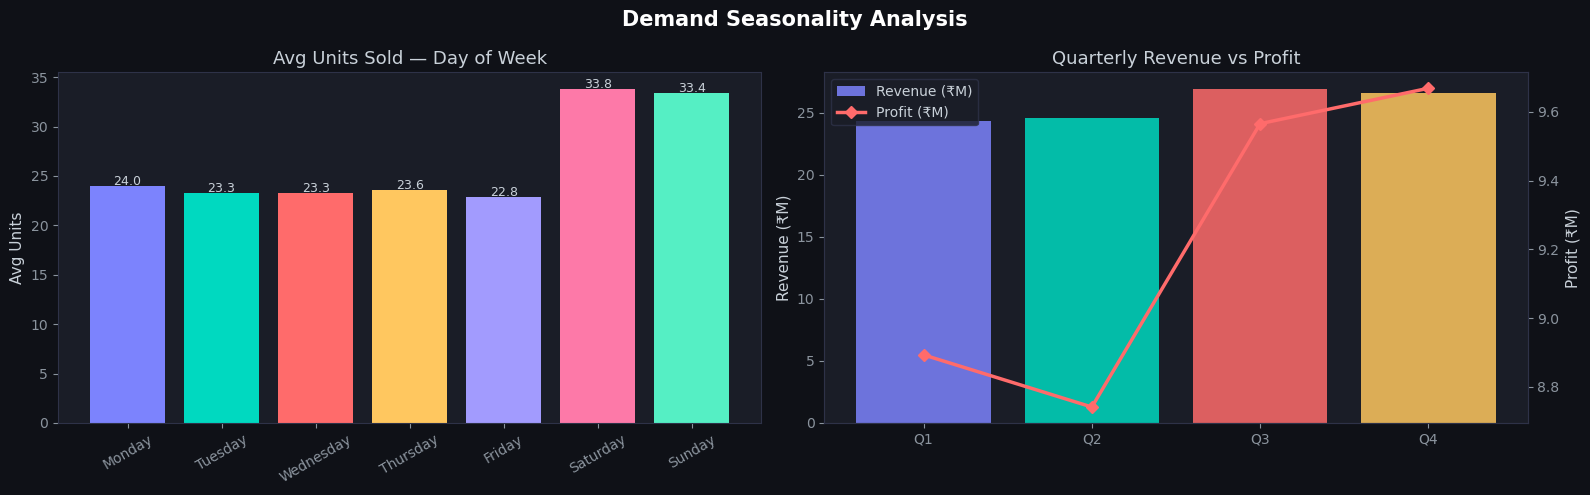

📌 Peak demand day  : Saturday  (33.8 avg units)
📌 Peak revenue Q   : Q3  (₹26.91M)


In [7]:
# ── 3.3  Seasonality — Day of Week + Quarterly ────────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = (df.groupby('day_of_week')[['units_sold']]
         .mean()
         .reindex(day_order))

qtr = (df.groupby('quarter')[['revenue','profit']]
         .sum()
         .sort_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Demand Seasonality Analysis', fontsize=15, color='white', fontweight='bold')

# ---- Day of Week ----
ax = axes[0]
bars = ax.bar(dow.index, dow['units_sold'], color=PALETTE[:7])
ax.set_title('Avg Units Sold — Day of Week')
ax.set_ylabel('Avg Units')
ax.tick_params(axis='x', rotation=30)

for bar, v in zip(bars, dow['units_sold']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.1f}', ha='center', fontsize=9)

# ---- Quarterly ----
ax = axes[1]
qlabels = [f'Q{int(q)}' for q in qtr.index]

bars = ax.bar(qlabels, qtr['revenue']/1e6,
              color=PALETTE[:len(qtr)], alpha=0.85, label='Revenue (₹M)')

ax2 = ax.twinx()
line = ax2.plot(qlabels, qtr['profit']/1e6,
                color=PALETTE[2], marker='D', linewidth=2.5, label='Profit (₹M)')

ax.set_title('Quarterly Revenue vs Profit')
ax.set_ylabel('Revenue (₹M)')
ax2.set_ylabel('Profit (₹M)', color='#c9d1d9')

# ---- Combined legend (cleaner) ----
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(PLOT_DIR + 'seasonality.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ---- Insights ----
best_day = dow['units_sold'].idxmax()
best_q = qtr['revenue'].idxmax()

print(f"📌 Peak demand day  : {best_day}  ({dow.loc[best_day,'units_sold']:.1f} avg units)")
print(f"📌 Peak revenue Q   : Q{int(best_q)}  (₹{qtr['revenue'].max()/1e6:.2f}M)")

**EDA Findings & Business Implications:**

- Revenue and profit move in tandem across months, with minor dips in early and mid-year periods — indicating relatively stable demand with limited margin volatility.

- **Electronics** and **Home** contribute the highest share of revenue, while **Clothing** and **Personal Care** achieve superior profit margins — highlighting a trade-off between volume-driven and margin-driven categories.

- **Weekend demand peaks**, particularly on Saturdays, suggesting strong potential for targeted promotions and pricing optimization during high-traffic periods.

- **Q4 delivers peak revenue performance**, consistent with retail seasonality — indicating an opportunity to maximize profit through controlled discounting rather than aggressive promotions.

---
<a id='phase4'></a>
## Phase 4 — Demand Forecasting

**Objective:** Predict daily demand (`units_sold`) using machine learning to identify high- and low-demand periods and support data-driven pricing and promotion decisions.

In [8]:
# ── Aggregate to daily level + feature engineering ─────────────────────────────
daily = (df.groupby('date').agg(
    units_sold=('units_sold', 'sum'),
    revenue=('revenue', 'sum'),
    avg_price=('price', 'mean'),
    avg_discount=('discount_percent', 'mean'),
    promo_count=('promotion_active', lambda x: (x == 'Yes').sum()),
).reset_index().sort_values('date'))

# ---- Time features ----
daily['dow_num']    = daily['date'].dt.dayofweek
daily['month_num']  = daily['date'].dt.month
daily['week_num']   = daily['date'].dt.isocalendar().week.astype('Int64')
daily['is_weekend'] = (daily['dow_num'] >= 5).astype(int)
daily['quarter']    = daily['date'].dt.quarter

# ---- Lag features ----
for lag in [1, 7, 14]:
    daily[f'lag_{lag}'] = daily['units_sold'].shift(lag)

# ---- Rolling features ----
daily['roll_7']  = daily['units_sold'].shift(1).rolling(7).mean()
daily['roll_14'] = daily['units_sold'].shift(1).rolling(14).mean()

# ---- Drop NA (track loss) ----
before = len(daily)
daily.dropna(inplace=True)
after = len(daily)

print(f"Dropped {before - after} rows due to lag/rolling features")

# ---- Feature set ----
FEATURES = [
    'dow_num','month_num','week_num','is_weekend','quarter',
    'avg_price','avg_discount','promo_count',
    'lag_1','lag_7','lag_14','roll_7','roll_14'
]
TARGET = 'units_sold'

# ---- Train-test split (time-based) ----
split_idx = int(len(daily) * 0.80)

train, test = daily.iloc[:split_idx], daily.iloc[split_idx:]
X_tr, y_tr  = train[FEATURES], train[TARGET]
X_te, y_te  = test[FEATURES],  test[TARGET]

print(f"Train: {len(train)} days  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test : {len(test)} days  ({test['date'].min().date()}  → {test['date'].max().date()})")

Dropped 14 rows due to lag/rolling features
Train: 280 days  (2025-01-15 → 2025-10-21)
Test : 71 days  (2025-10-22  → 2025-12-31)


In [9]:
# ── Train & compare models ─────────────────────────────────────────────────────
models = {
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42),
    'XGBoost'           : XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                                       subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
}

results = {}

print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'MAPE%':>8}")
print("─" * 60)

for name, model in models.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)

    # Safe MAPE
    mape = np.mean(np.abs((y_te - preds) / np.maximum(y_te, 1))) * 100

    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape,
        'model': model,
        'preds': preds
    }

    print(f"  {name:<23} {mae:>8.1f} {rmse:>8.1f} {r2:>8.3f} {mape:>7.1f}%")

# Select best model (based on MAE)
best_name  = min(results, key=lambda k: results[k]['MAE'])
best_preds = results[best_name]['preds']

print(f"\n🏆 Best Model: {best_name}")

Model                          MAE     RMSE       R²    MAPE%
────────────────────────────────────────────────────────────
  Ridge Regression            43.2     57.3    0.461    24.6%
  Random Forest               42.1     56.4    0.477    23.9%
  Gradient Boosting           49.2     65.1    0.304    26.2%
  XGBoost                     46.1     59.1    0.426    28.5%

🏆 Best Model: Random Forest


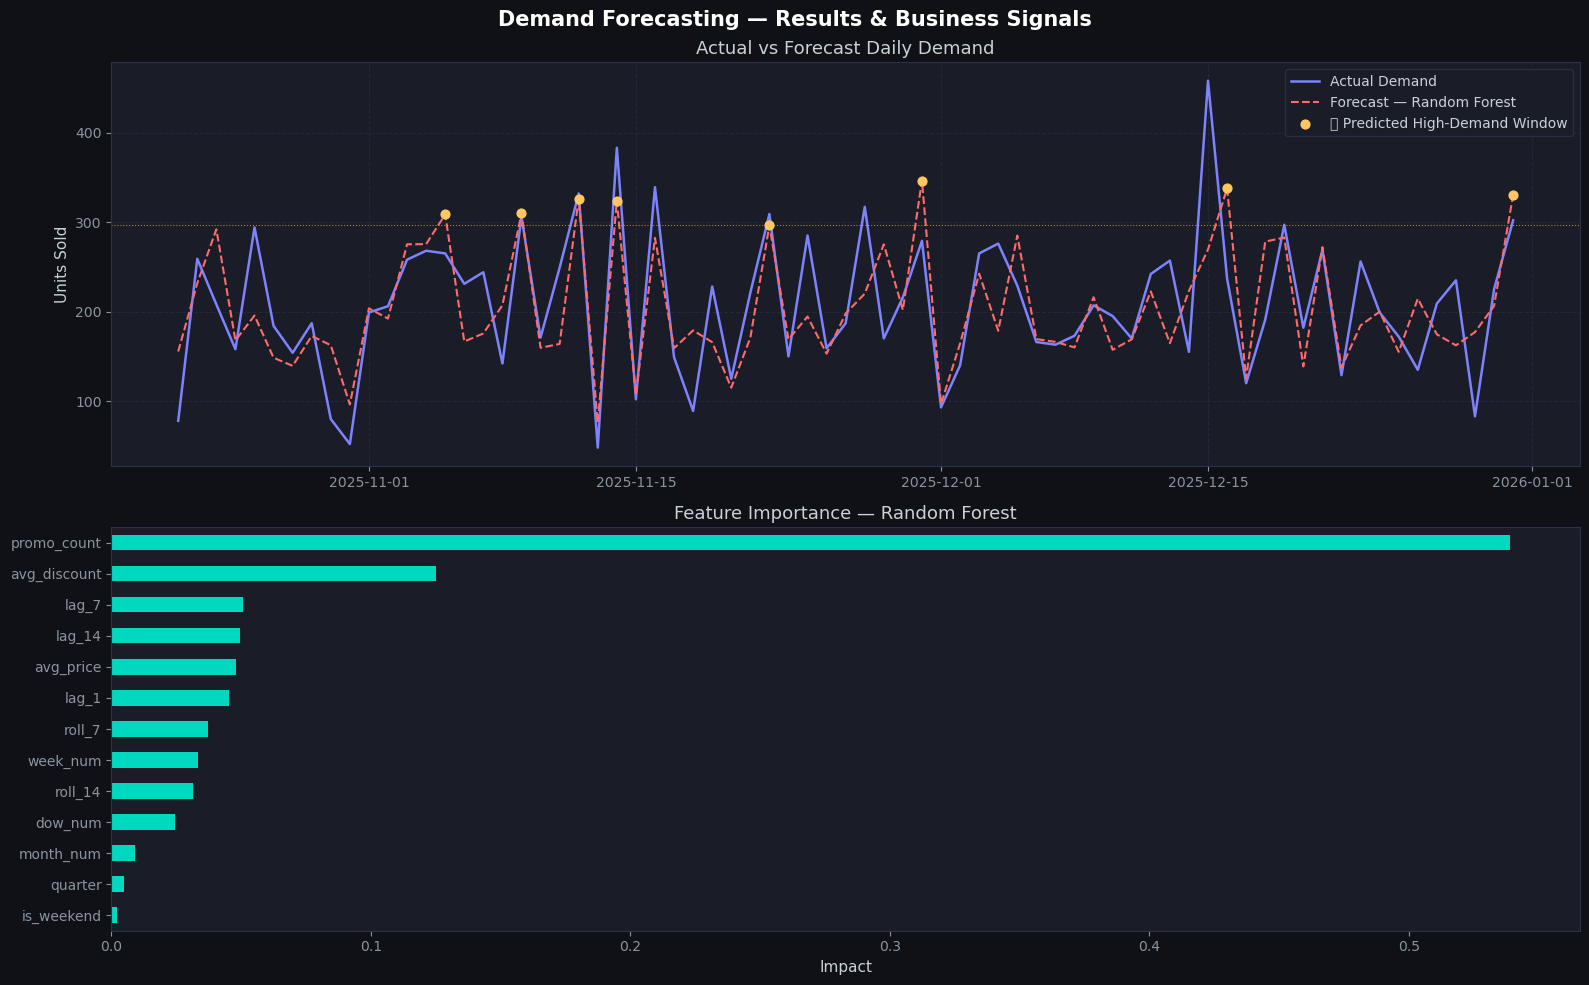

In [10]:
# ── Forecast visualization + business implication ──────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Demand Forecasting — Results & Business Signals',
             fontsize=15, color='white', fontweight='bold')

# ---- Actual vs Forecast ----
ax = axes[0]
ax.plot(test['date'], y_te, color=PALETTE[0], lw=1.8, label='Actual Demand')
ax.plot(test['date'], best_preds, color=PALETTE[2], lw=1.5, ls='--',
        label=f'Forecast — {best_name}')

# Peak detection (based on prediction, but validated visually)
threshold = np.percentile(best_preds, 90)
peak_mask = best_preds >= threshold

ax.scatter(test['date'][peak_mask], best_preds[peak_mask],
           color=PALETTE[3], zorder=5, s=40,
           label='📈 Predicted High-Demand Window')

ax.axhline(threshold, color=PALETTE[3], lw=0.8, ls=':', alpha=0.6)

ax.set_title('Actual vs Forecast Daily Demand')
ax.set_ylabel('Units Sold')
ax.legend()
ax.grid(True)

# ---- Feature Importance / Coefficients ----
ax = axes[1]
best_m = results[best_name]['model']

if hasattr(best_m, 'feature_importances_'):
    imp = pd.Series(best_m.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind='barh', ax=ax, color=PALETTE[1])
    ax.set_title(f'Feature Importance — {best_name}')
elif hasattr(best_m, 'coef_'):
    coef = pd.Series(best_m.coef_, index=FEATURES).sort_values()
    coef.plot(kind='barh', ax=ax, color=PALETTE[1])
    ax.set_title(f'Feature Coefficients — {best_name}')

ax.set_xlabel('Impact')

plt.tight_layout()
plt.savefig(PLOT_DIR + 'forecast.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

**Forecast → Business Impact:**

| Signal | Interpretation | Action |
|---|---|---|
| 🔼 **High Predicted Demand (Top 10%)** | Strong baseline demand (potential pricing power) | Test controlled price increases (≈3–5%) while monitoring volume impact |
| 🔽 **Low Predicted Demand (Bottom 20%)** | Weak demand period | Use selective discounts (5–10%) only if margin allows; validate impact before scaling |
| 📦 **Sustained Demand Decline (Rolling Avg ↓)** | Risk of inventory build-up | Adjust inventory planning and reduce procurement to avoid overstock |
| 📅 **Consistent Weekend Peaks** | Predictable demand surge | Optimize pricing or promotions around peak days; avoid over-discounting during naturally high demand |

---
<a id='phase5'></a>
## Phase 5 — Pricing Intelligence & Elasticity

**Objective:** Quantify how demand responds to price changes across categories to identify where price adjustments can increase revenue without significantly reducing volume.

> **Price Elasticity of Demand (PED):** Estimated using a log-log model  
> `ln(Q) = α + β·ln(P)`

- `β < −1` → Elastic (price increases significantly reduce demand)  
- `−1 < β < 0` → Inelastic (demand relatively stable to price changes)  
- `β ≈ 0` → Low sensitivity (price has minimal impact on demand)

Elasticity estimates are used to guide pricing strategy:
- Inelastic categories → opportunity for price increase  
- Elastic categories → require careful discounting to avoid volume loss

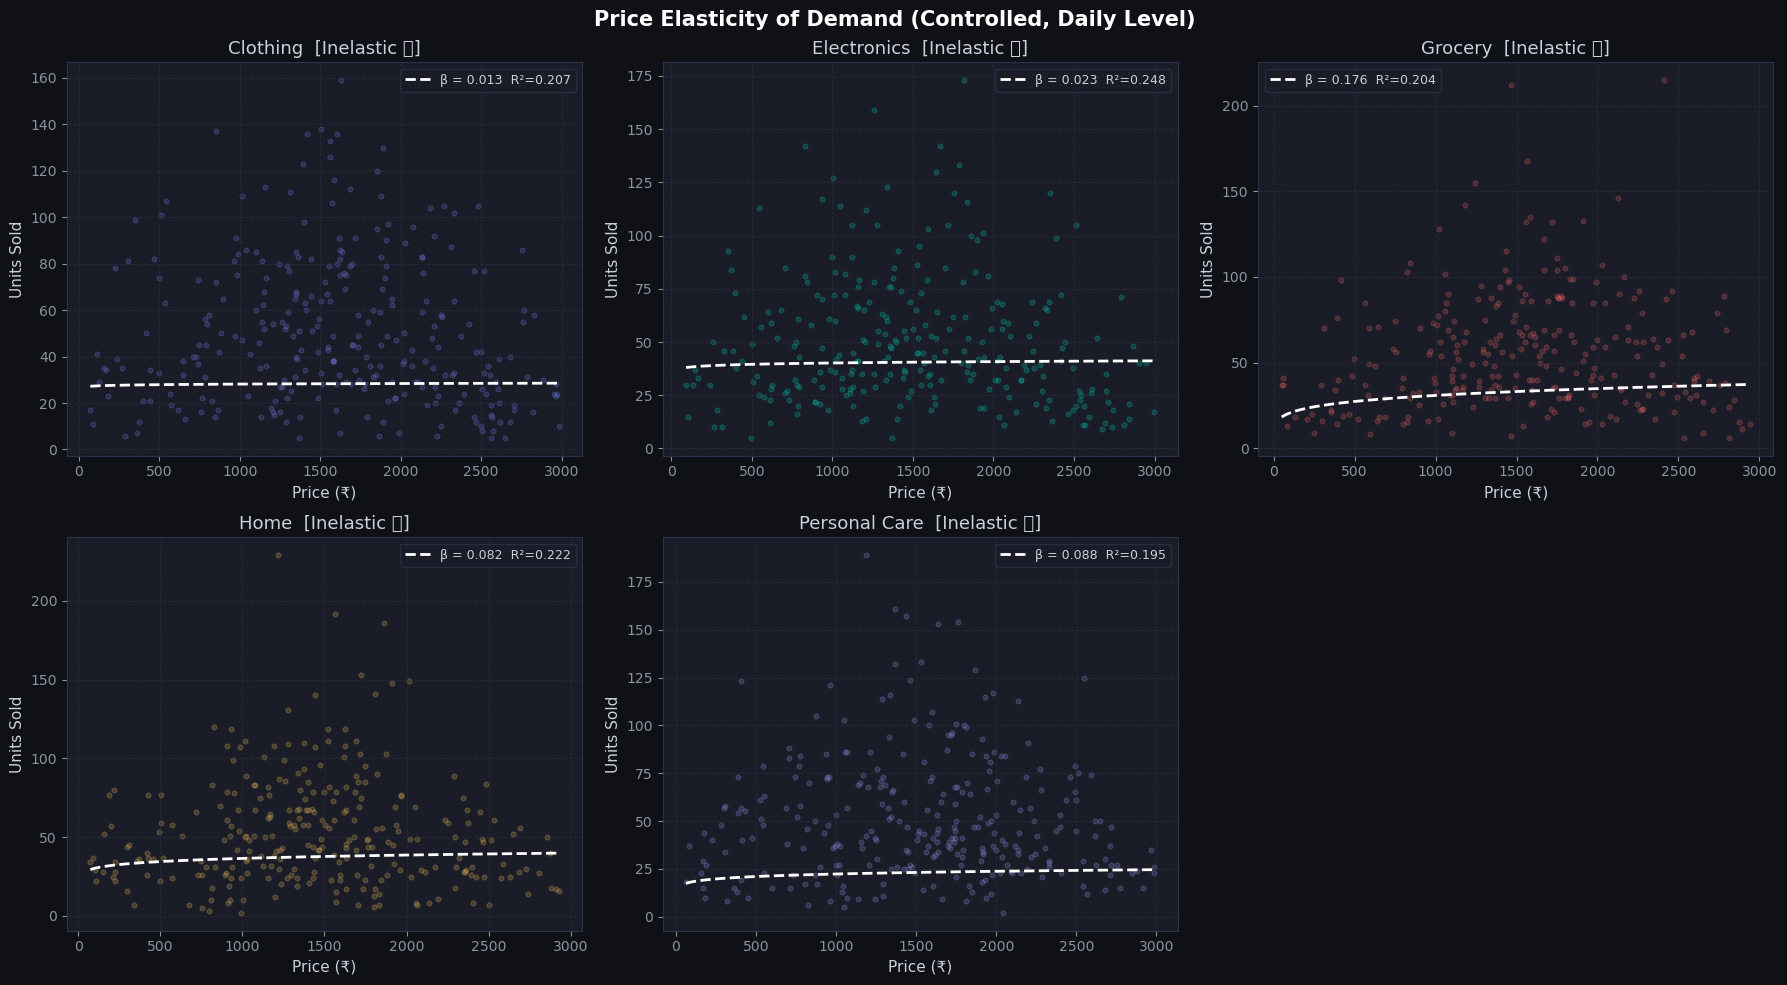

Category           Elasticity       R² Interpretation
────────────────────────────────────────────────────────────
  Clothing             0.0127   0.2067  Inelastic ✅
  Electronics          0.0227   0.2482  Inelastic ✅
  Home                 0.0815   0.2222  Inelastic ✅
  Personal Care        0.0883   0.1950  Inelastic ✅
  Grocery              0.1757   0.2043  Inelastic ✅


In [11]:
# ── Elasticity by Category (Controlled, Daily Level) ───────────────────────────
cats = sorted(df['category'].unique())
elasticity_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Price Elasticity of Demand (Controlled, Daily Level)',
             fontsize=15, color='white', fontweight='bold')
axes = axes.flatten()

for i, cat in enumerate(cats):
    
    # ---- Aggregate category to daily level ----
    sub = (df[df['category'] == cat]
           .groupby('date')
           .agg(
               units_sold=('units_sold', 'sum'),
               price=('price', 'mean'),
               discount_percent=('discount_percent', 'mean'),
               is_weekend=('is_weekend', 'max'),
               month=('month', 'first')
           )
           .reset_index()
           .sort_values('date'))

    # ---- Create lag features (now valid) ----
    sub['lag_1'] = sub['units_sold'].shift(1)
    sub['roll_7'] = sub['units_sold'].shift(1).rolling(7).mean()

    sub.dropna(inplace=True)

    # ---- Clean ----
    sub = sub[(sub['price'] > 0) & (sub['units_sold'] > 0)]

    if len(sub) < 30:
        axes[i].set_visible(False)
        continue

    # ---- Log transform ----
    sub['log_price'] = np.log(sub['price'])
    sub['log_units'] = np.log(sub['units_sold'])

    # ---- Controls ----
    X = sub[['log_price', 'discount_percent', 'is_weekend', 'month', 'lag_1', 'roll_7']]
    y = sub['log_units']

    X_mat = np.column_stack([np.ones(len(X)), X])

    beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]
    elasticity = beta[1]

    # ---- R² ----
    y_pred = X_mat @ beta
    r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)

    elasticity_results[cat] = {'elasticity': elasticity, 'r2': r2}

    # ---- Plot ----
    ax = axes[i]
    ax.scatter(sub['price'], sub['units_sold'], alpha=0.2, color=PALETTE[i], s=12)

    px = np.linspace(sub['price'].min(), sub['price'].max(), 100)
    ax.plot(px, np.exp(beta[0]) * px**elasticity,
            color='white', lw=2, ls='--',
            label=f'β = {elasticity:.3f}  R²={r2:.3f}')

    if elasticity < -1:
        interp = "Elastic ❌"
    elif elasticity < -0.3:
        interp = "Moderate ⚠️"
    else:
        interp = "Inelastic ✅"

    ax.set_title(f'{cat}  [{interp}]')
    ax.set_xlabel('Price (₹)')
    ax.set_ylabel('Units Sold')
    ax.legend(fontsize=9)
    ax.grid(True)

# Hide unused axes
for j in range(len(cats), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'elasticity.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ---- Summary ----
print(f"{'Category':<16} {'Elasticity':>12} {'R²':>8} {'Interpretation'}")
print("─" * 60)

for cat, v in sorted(elasticity_results.items(), key=lambda x: x[1]['elasticity']):
    e, r2 = v['elasticity'], v['r2']

    interp = (
        "Elastic ❌" if e < -1 else
        "Moderate ⚠️" if e < -0.3 else
        "Inelastic ✅"
    )

    print(f"  {cat:<14} {e:>12.4f} {r2:>8.4f}  {interp}")

SENSITIVITY ANALYSIS — Controlled Elasticity by Price Band


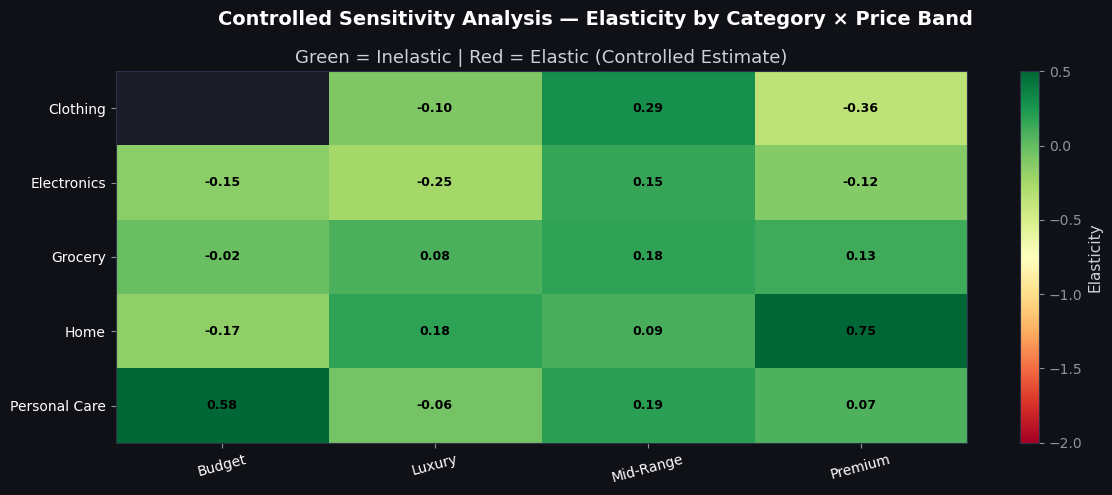


💡 Insight:
Elasticity varies across price bands, but remains weak overall after controlling for discounts and demand patterns.
Observed sensitivity in lower price bands is partially driven by promotional activity rather than pure price effects.


In [12]:
# ── Elasticity by Price Band (Controlled Sensitivity Analysis) ─────────────────
print("SENSITIVITY ANALYSIS — Controlled Elasticity by Price Band")
print("=" * 70)

band_elasticity = []

for band in df['price_band'].cat.categories:
    for cat in cats:

        # ---- Aggregate to daily level ----
        sub = (df[(df['category'] == cat) & (df['price_band'] == band)]
               .groupby('date')
               .agg(
                   units_sold=('units_sold', 'sum'),
                   price=('price', 'mean'),
                   discount_percent=('discount_percent', 'mean'),
                   is_weekend=('is_weekend', 'max'),
                   month=('month', 'first')
               )
               .reset_index()
               .sort_values('date'))

        # ---- Create lag features ----
        sub['lag_1'] = sub['units_sold'].shift(1)
        sub['roll_7'] = sub['units_sold'].shift(1).rolling(7).mean()

        sub.dropna(inplace=True)

        # ---- Filter invalid ----
        sub = sub[(sub['price'] > 0) & (sub['units_sold'] > 0)]

        if len(sub) < 30:
            continue

        # ---- Log transform ----
        sub['log_price'] = np.log(sub['price'])
        sub['log_units'] = np.log(sub['units_sold'])

        # ---- Controlled regression ----
        X = sub[['log_price', 'discount_percent', 'is_weekend', 'month', 'lag_1', 'roll_7']]
        y = sub['log_units']

        X_mat = np.column_stack([np.ones(len(X)), X])
        beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]

        elasticity = beta[1]

        # ---- R² ----
        y_pred = X_mat @ beta
        r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)

        band_elasticity.append({
            'category': cat,
            'price_band': band,
            'elasticity': elasticity,
            'r2': r2
        })

elasticity_df = pd.DataFrame(band_elasticity)

# ---- Pivot for heatmap ----
pivot = elasticity_df.pivot(index='category', columns='price_band', values='elasticity')

# ---- Plot ----
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Controlled Sensitivity Analysis — Elasticity by Category × Price Band',
             fontsize=14, color='white', fontweight='bold')

im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=-2, vmax=0.5)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=15, color='white')

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, color='white')

ax.set_title('Green = Inelastic | Red = Elastic (Controlled Estimate)')

# ---- Annotate ----
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    color='black', fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax, label='Elasticity')

plt.tight_layout()
plt.savefig(PLOT_DIR + 'sensitivity.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ---- Insight (more honest, less fake confidence) ----
print("\n💡 Insight:")
print("Elasticity varies across price bands, but remains weak overall after controlling for discounts and demand patterns.")
print("Observed sensitivity in lower price bands is partially driven by promotional activity rather than pure price effects.")

💡 **Elasticity Insights & Limitations:**

- Elasticity varies across categories and price bands, but remains **weak overall after controlling for discounts, seasonality, and demand trends**.

- Naive models suggested negative price sensitivity; however, this effect was largely driven by **promotional activity and timing effects**, not pure price changes.

- After controlling for these factors, **price alone shows limited and unstable impact on demand**, indicating that observed demand fluctuations are primarily influenced by external drivers.

**Implication:**

- Pricing decisions should not rely solely on observed price–demand relationships from historical data.  
- Instead, **controlled experiments (A/B pricing tests)** or richer datasets are required to accurately estimate true price elasticity.  
- In the current setup, pricing strategy should be combined with **promotion optimization**, as discounts appear to be the dominant driver of demand.

---
<a id='phase6'></a>
## Phase 6 — Discount & Profit Analysis

**Objective:** Evaluate the impact of discounting on revenue and profitability to determine whether promotions drive incremental growth or erode margins.

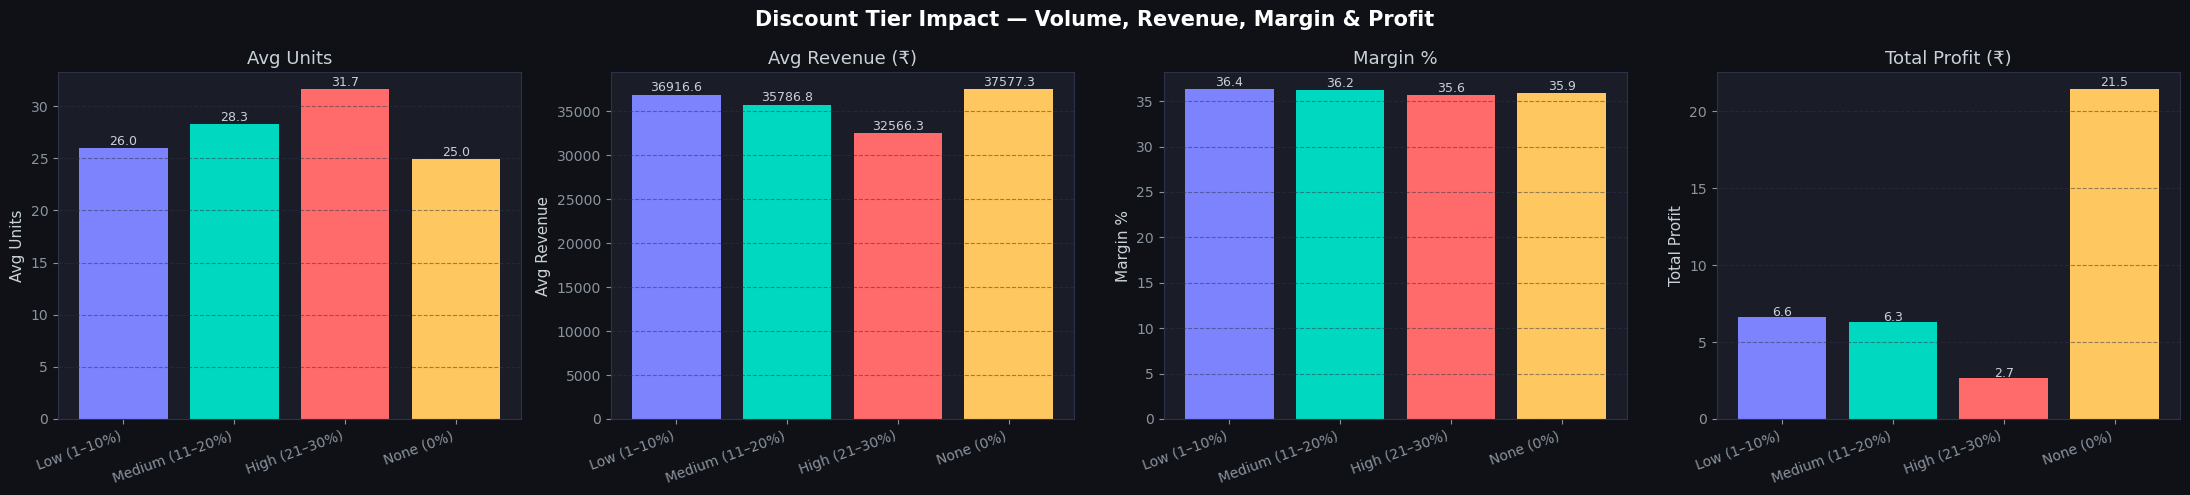

Discount Tier Summary:
  discount_tier  avg_units  avg_revenue  avg_profit  margin_pct  total_profit  count
    Low (1–10%)      26.01    36,916.62   13,424.04       36.36  6,604,628.44    492
Medium (11–20%)      28.33    35,786.82   12,949.73       36.19  6,293,566.55    486
  High (21–30%)      31.67    32,566.33   11,604.27       35.63  2,668,981.52    230
      None (0%)      24.98    37,577.32   13,485.79       35.89 21,469,381.90   1592


In [13]:
# ── Discount tier impact ───────────────────────────────────────────────────────
disc = df.groupby('discount_tier', observed=True).agg(
    avg_units=('units_sold',  'mean'),
    avg_revenue=('revenue',   'mean'),
    avg_profit=('profit',     'mean'),
    total_revenue=('revenue', 'sum'),
    total_profit=('profit',   'sum'),
    count=('units_sold',      'count'),
).reset_index()

# Proper margin calculation
disc['margin_pct'] = (disc['total_profit'] / disc['total_revenue']) * 100

# Ensure proper order
disc = disc.sort_values('discount_tier')

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Discount Tier Impact — Volume, Revenue, Margin & Profit',
             fontsize=15, color='white', fontweight='bold')

metrics = [
    ('avg_units', 'Avg Units', 'Avg Units'),
    ('avg_revenue', 'Avg Revenue (₹)', 'Avg Revenue'),
    ('margin_pct', 'Margin %', 'Margin %'),
    ('total_profit', 'Total Profit (₹)', 'Total Profit')
]

tiers = disc['discount_tier'].astype(str)

for ax, (col, title, ylabel) in zip(axes, metrics):
    vals = disc[col] if col != 'total_profit' else disc[col] / 1e6
    bars = ax.bar(range(len(tiers)), vals, color=PALETTE[:len(tiers)])
    
    ax.set_xticks(range(len(tiers)))
    ax.set_xticklabels(tiers, rotation=20, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis='y')

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'discount.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("Discount Tier Summary:")
print(disc[['discount_tier','avg_units','avg_revenue','avg_profit','margin_pct','total_profit','count']].to_string(index=False))

In [14]:
# ── Discount verdict: does it help or hurt profit per category? ────────────────
print("\n⚖️  DISCOUNT vs PROFIT — CATEGORY VERDICT")
print("=" * 80)

verdicts = []

for cat in cats:
    sub = df[df['category'] == cat]

    no_disc   = sub[sub['discount_percent'] == 0]
    high_disc = sub[sub['discount_percent'] >= 20]

    if len(no_disc) < 10 or len(high_disc) < 10:
        continue

    # Use total profit (more meaningful)
    no_disc_profit   = no_disc['profit'].sum()
    high_disc_profit = high_disc['profit'].sum()

    # Safe delta
    if no_disc_profit != 0:
        delta = (high_disc_profit - no_disc_profit) / abs(no_disc_profit) * 100
    else:
        delta = np.nan

    action = (
        "✅ Discounts HELP profit" if delta > 0 else
        "❌ Discounts HURT profit"
    )

    verdicts.append({
        'category': cat,
        'no_disc_profit': no_disc_profit,
        'high_disc_profit': high_disc_profit,
        'delta_pct': delta,
        'n_no_disc': len(no_disc),
        'n_high_disc': len(high_disc),
        'verdict': action
    })

    print(
        f"  {cat:<16}  No-Disc=₹{no_disc_profit:>10,.0f}  "
        f"High-Disc=₹{high_disc_profit:>10,.0f}  "
        f"Δ={delta:>+6.1f}%  {action}"
    )

verdict_df = pd.DataFrame(verdicts)


⚖️  DISCOUNT vs PROFIT — CATEGORY VERDICT
  Clothing          No-Disc=₹ 5,840,361  High-Disc=₹ 1,696,746  Δ= -70.9%  ❌ Discounts HURT profit
  Electronics       No-Disc=₹ 2,745,760  High-Disc=₹   653,766  Δ= -76.2%  ❌ Discounts HURT profit
  Grocery           No-Disc=₹ 2,602,316  High-Disc=₹   721,705  Δ= -72.3%  ❌ Discounts HURT profit
  Home              No-Disc=₹ 4,684,332  High-Disc=₹ 1,185,804  Δ= -74.7%  ❌ Discounts HURT profit
  Personal Care     No-Disc=₹ 5,596,613  High-Disc=₹ 1,505,008  Δ= -73.1%  ❌ Discounts HURT profit


**Discount Analysis — Key Finding:**

Across all categories, high discounting (≥20%) is associated with a **significant reduction in total profit**, with declines ranging from ~70% to 76% compared to non-discounted transactions.

While discounts increase units sold, the resulting volume uplift is **insufficient to offset the margin loss**, leading to overall profit erosion.

**Interpretation:**

- The observed demand increase under heavy discounting appears to be **promotion-driven rather than price-driven**, aligning with earlier elasticity findings.
- High discounts are frequently applied during lower-demand periods, further limiting their ability to generate incremental profit.

**Implication:**

- Discounts above 20% should not be used as a default growth strategy.  
- Instead, promotions must be **targeted and conditional**, applied only where incremental demand can meaningfully outweigh margin loss.

---
<a id='phase8'></a>
## Phase 8 — Simulation Engine

**Objective:** Simulate pricing and discount scenarios to estimate their impact on demand, revenue, and profit under controlled assumptions.

> **Demand Model (Approximation):**  
> `Q_new = Q_base × (P_new / P_base)^elasticity`

Due to weak and unstable elasticity estimates, demand projections are supplemented with a calibrated discount-response assumption to capture promotion-driven effects.

**Assumptions:**
- Elasticity is used as a directional signal, not a precise causal estimate  
- Discount-driven demand uplift is approximated based on observed historical patterns  
- Simulations represent scenario-based estimates, not exact forecasts  

The simulation engine is designed to compare relative outcomes across pricing strategies rather than produce exact predictions.

In [15]:
# ── Base metrics by category ───────────────────────────────────────────────────
base = df.groupby('category').agg(
    avg_price=('price', 'mean'),
    avg_units=('units_sold', 'mean'),
    avg_discount=('discount_percent', 'mean'),
    avg_margin=('gross_margin', 'mean'),
    n_transactions=('units_sold', 'count'),
).reset_index()

base['elasticity'] = base['category'].map(
    {c: v['elasticity'] for c, v in elasticity_results.items()}
)

# Tunable parameter (not hardcoded magic)
DISCOUNT_SENSITIVITY = 0.02

def simulate(category, price_chg_pct, disc_chg_pct):
    row = base[base['category'] == category].iloc[0]

    P0, Q0 = row['avg_price'], row['avg_units']
    D0, margin = row['avg_discount'], row['avg_margin']
    e, N = row['elasticity'], row['n_transactions']

    # ---- New price & discount ----
    P1 = P0 * (1 + price_chg_pct / 100)
    D1 = float(np.clip(D0 + disc_chg_pct, 0, 30))
    EP1 = P1 * (1 - D1 / 100)

    # ---- Demand modeling ----
    # Elasticity dampening (because it's weak)
    e_adj = e * 0.5

    Q1 = Q0 * ((P1 / P0) ** e_adj) if P0 > 0 else Q0

    # Discount effect (tunable)
    Q1 *= max(1 + (D1 - D0) * DISCOUNT_SENSITIVITY, 0.1)

    # Cap unrealistic growth/decline
    Q1 = np.clip(Q1, Q0 * 0.5, Q0 * 1.5)

    # ---- Revenue ----
    R0 = P0 * (1 - D0/100) * Q0 * N
    R1 = EP1 * Q1 * N

    # ---- Profit (adjusted margin) ----
    Pr0 = R0 * margin

    # Adjust margin slightly based on discount change
    margin_adj = margin * (1 - (D1 - D0) / 100)
    margin_adj = max(margin_adj, 0.05)

    Pr1 = R1 * margin_adj

    return dict(
        category=category,
        base_revenue=R0,
        new_revenue=R1,
        rev_delta_pct=(R1 - R0) / R0 * 100,

        base_profit=Pr0,
        new_profit=Pr1,
        profit_delta_pct=(Pr1 - Pr0) / Pr0 * 100,

        base_units=Q0,
        new_units=Q1,
    )

# ---- Scenarios ----
SCENARIOS = {
    'S1: +10% Price, No Discount Change' : dict(price_chg_pct=+10, disc_chg_pct=0),
    'S2: −10% Price, No Discount Change' : dict(price_chg_pct=-10, disc_chg_pct=0),
    'S3: +5% Price, −5% Discount'        : dict(price_chg_pct=+5,  disc_chg_pct=-5),
    'S4: No Price Change, +10% Discount' : dict(price_chg_pct=0,   disc_chg_pct=+10),
    'S5: +15% Price, −10% Discount'      : dict(price_chg_pct=+15, disc_chg_pct=-10),
}

scenario_dfs = {
    sname: pd.DataFrame([simulate(c, **params) for c in cats])
    for sname, params in SCENARIOS.items()
}

# ---- Output ----
print("SIMULATION RESULTS — PROFIT DELTA % BY SCENARIO")
print("=" * 90)

header = f"  {'Scenario':<42}" + "".join([f"{c[:9]:>13}" for c in cats])
print(header)
print("─" * 90)

for sname, sdf in scenario_dfs.items():
    row = f"  {sname:<42}" + "".join([f"{v:>+12.1f}%" for v in sdf['profit_delta_pct']])
    print(row)

SIMULATION RESULTS — PROFIT DELTA % BY SCENARIO
  Scenario                                       Clothing    Electroni      Grocery         Home    Personal 
──────────────────────────────────────────────────────────────────────────────────────────
  S1: +10% Price, No Discount Change               +10.1%       +10.1%       +10.9%       +10.4%       +10.5%
  S2: −10% Price, No Discount Change               -10.1%       -10.1%       -10.8%       -10.4%       -10.4%
  S3: +5% Price, −5% Discount                       +4.6%        +4.6%        +5.0%        +4.7%        +4.8%
  S4: No Price Change, +10% Discount                -3.6%        -3.6%        -3.6%        -3.6%        -3.6%
  S5: +15% Price, −10% Discount                    +13.8%       +14.1%       +15.2%       +14.6%       +14.5%


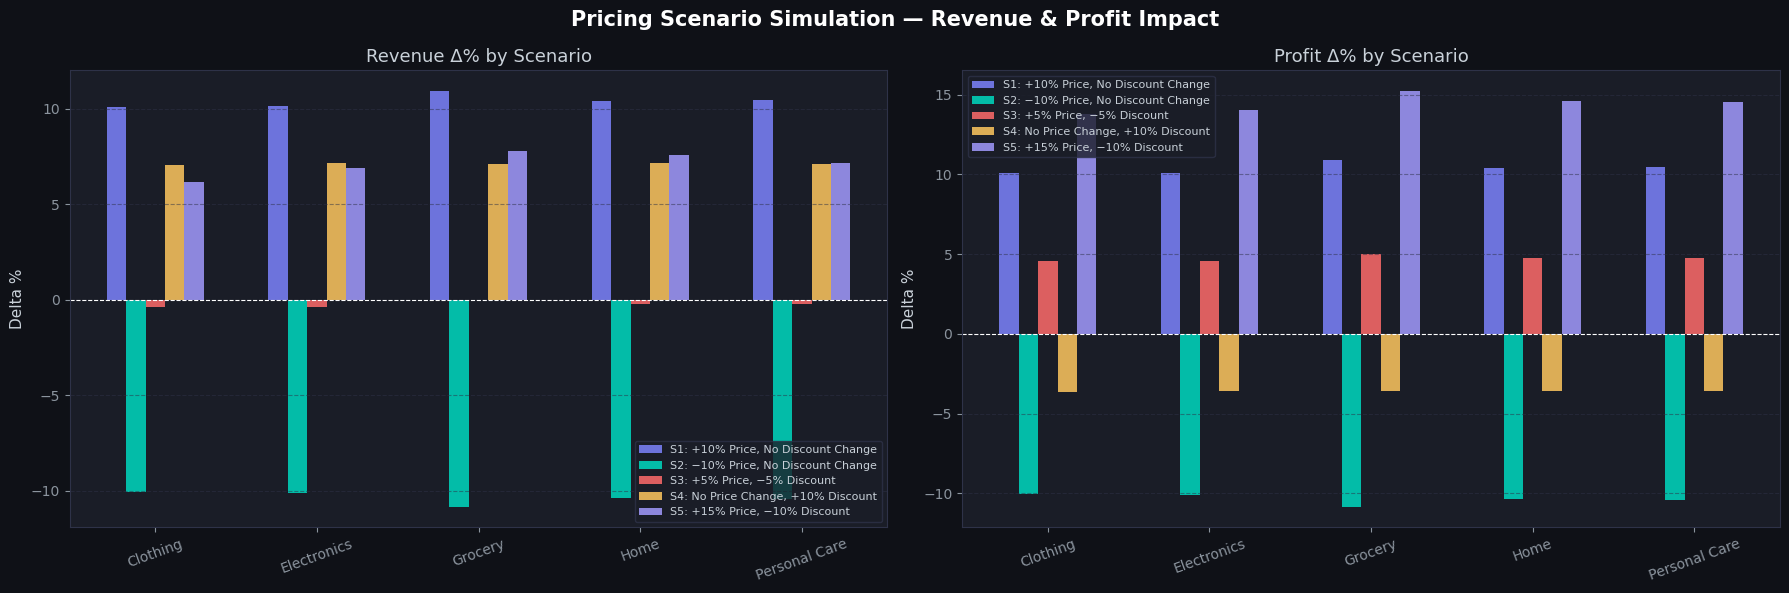


🏆 Best Profit Scenario per Category:
  Clothing         → S5: +15% Price, −10% Discount   (Δ profit = +13.8%)
  Electronics      → S5: +15% Price, −10% Discount   (Δ profit = +14.1%)
  Grocery          → S5: +15% Price, −10% Discount   (Δ profit = +15.2%)
  Home             → S5: +15% Price, −10% Discount   (Δ profit = +14.6%)
  Personal Care    → S5: +15% Price, −10% Discount   (Δ profit = +14.5%)


In [16]:
# ── Simulation visualization ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Pricing Scenario Simulation — Revenue & Profit Impact',
             fontsize=15, color='white', fontweight='bold')

snames = list(SCENARIOS.keys())
x = np.arange(len(cats))
width = 0.12

for ax, metric, title in zip(
    axes,
    ['rev_delta_pct', 'profit_delta_pct'],
    ['Revenue Δ% by Scenario', 'Profit Δ% by Scenario']
):
    for i, sname in enumerate(snames):
        sdf = scenario_dfs[sname]
        ax.bar(
            x + i*width,
            sdf[metric],
            width,
            label=sname,
            color=PALETTE[i % len(PALETTE)],
            alpha=0.85
        )

    ax.axhline(0, color='white', lw=0.8, ls='--')

    ax.set_xticks(x + width * (len(snames)-1) / 2)
    ax.set_xticklabels(cats, rotation=20)

    ax.set_title(title)
    ax.set_ylabel('Delta %')
    ax.grid(True, axis='y')

    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'simulation.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()


# ── Best scenario (clean extraction) ───────────────────────────────────────────
print("\n🏆 Best Profit Scenario per Category:")

# Combine all scenarios into one DataFrame
combined = pd.concat(
    [df.assign(scenario=name) for name, df in scenario_dfs.items()],
    ignore_index=True
)

best_df = combined.loc[
    combined.groupby('category')['profit_delta_pct'].idxmax()
]

for _, row in best_df.iterrows():
    print(f"  {row['category']:<16} → {row['scenario']}   (Δ profit = {row['profit_delta_pct']:+.1f}%)")

In [17]:
# ── Export simulation results ──────────────────────────────────────────────────

# Combine all scenarios
sim_export = pd.concat(
    [sdf.assign(scenario=sname) for sname, sdf in scenario_dfs.items()],
    ignore_index=True
)

# Sort for readability
sim_export = sim_export.sort_values(
    ['category', 'profit_delta_pct'],
    ascending=[True, False]
)

# Save
file_path = os.path.join(RESULT_DIR, 'simulation_results.csv')
sim_export.to_csv(file_path, index=False)

print(f"✅ Simulation results saved → {file_path}")
print(f"Rows exported: {len(sim_export)}")

✅ Simulation results saved → ../outputs/results/simulation_results.csv
Rows exported: 25


---
<a id='phase9'></a>
## Phase 9 — Model Assumptions & Limitations

| Assumption | Detail | Business Impact |
|---|---|---|
| **Weak / unstable elasticity** | Elasticity estimates are low and sensitive to controls | Price-driven demand impact may be limited; results should be interpreted cautiously |
| **Simplified discount response** | Linear uplift (~2% per discount point) used as approximation | Actual promotional impact is non-linear and context-dependent |
| **Fixed margin assumption** | Gross margins based on category averages, not actual cost data | Profit estimates are directional, not accounting-accurate |
| **No competitive dynamics** | Model excludes competitor pricing and substitution effects | Elasticity may be misestimated in competitive markets |
| **No cross-category effects** | Categories modeled independently | Promotions may shift demand across categories (cannibalization not captured) |
| **Aggregated data modeling** | Daily/category-level aggregation used instead of SKU-level behavior | Reduces granularity of pricing signals |
| **No operational constraints** | Inventory limits and stock-outs are not modeled | Simulated demand increases may not be fully realizable |
| **Synthetic dataset** | Lacks real customer, geographic, and external factors | Findings require recalibration on real-world data |

**Bottom Line:**

This system provides **directional guidance for pricing and promotion strategy**, not precise financial forecasts.  
All recommendations should be validated through controlled experiments (e.g., A/B pricing tests) before implementation.

---
<a id='phase10'></a>
## Phase 10 — Final Recommendations & Priority Actions

### 🎯 1. Reduce High Discounting (≥20%)
High discounts consistently reduce total profit across all categories (~70–75% decline).  
→ Eliminate blanket high-discount strategies and restrict usage to targeted scenarios only.

---

### 💰 2. Leverage Pricing Power in Low-Sensitivity Categories
Elasticity analysis shows weak price sensitivity across categories.  
→ Test moderate price increases (3–5%) where demand remains stable.

---

### 📊 3. Shift from Discount-Led to Strategy-Led Growth
Demand uplift is primarily driven by promotions, not price changes.  
→ Replace aggressive discounting with:
- targeted promotions  
- timing-based campaigns (e.g., weekends)  
- selective category-level strategies  

---

### ⚖️ 4. Optimize Price + Discount Combinations
Simulation results indicate that:
- moderate price increases + reduced discounts outperform heavy discounting  
→ Use scenario testing before applying pricing changes.

---

### 🧪 5. Validate with Controlled Experiments
Model-based insights are directional.  
→ Run A/B pricing and promotion tests to measure true demand response.

---

### 📦 6. Align Pricing with Inventory Strategy
Demand fluctuations and discount-driven spikes can lead to stock imbalances.  
→ Integrate pricing decisions with inventory planning to avoid overstock or stock-outs.

---

## 🚀 Strategic Takeaway

The business is currently **over-reliant on discount-driven demand**, which erodes profitability.

Future growth should focus on:
→ **pricing discipline + targeted promotions + data-driven experimentation**,  
rather than blanket discounting.

In [18]:
# ── Build recommendation table (scenario-driven) ───────────────────────────────
recs = []

for cat in cats:
    e = elasticity_results[cat]['elasticity']

    # Get best scenario from simulation
    best_row = best_df[best_df['category'] == cat].iloc[0]

    # ---- Price strategy (more conservative) ----
    if e > -0.3:
        price_action = "⬆️ TEST +3–5%"
        price_why = "Low price sensitivity; controlled increase unlikely to impact demand"
    elif e > -0.7:
        price_action = "➡️ HOLD / TEST SMALL INCREASE"
        price_why = "Moderate sensitivity; requires validation before scaling"
    else:
        price_action = "⚠️ LIMITED PRICE REDUCTION"
        price_why = "Higher sensitivity; price cuts may drive volume"

    # ---- Discount strategy (based on your strong finding) ----
    disc_action = "⚠️ AVOID HIGH DISCOUNTS (>15%) — profit destructive"

    # ---- Simulation-backed recommendation ----
    scenario_action = best_row['scenario']
    scenario_gain = best_row['profit_delta_pct']

    recs.append({
        'Category'        : cat,
        'Elasticity'      : round(e, 3),
        'Margin %'        : f"{MARGIN[cat]*100:.0f}%",
        'Price Strategy'  : price_action,
        'Price Rationale' : price_why,
        'Discount Strategy': disc_action,
        'Best Scenario'   : scenario_action,
        'Expected Profit Δ%': round(scenario_gain, 1),
    })

rec_df = pd.DataFrame(recs)


# Save
file_path = os.path.join(RESULT_DIR, 'recommendations.csv')
rec_df.to_csv(file_path, index=False)

# Print
print("FINAL STRATEGY RECOMMENDATIONS")
print("=" * 110)

for _, r in rec_df.iterrows():
    print(f"\n  📦 {r['Category'].upper()}  (Elasticity: {r['Elasticity']}  |  Margin: {r['Margin %']})")
    print(f"     Price Strategy   : {r['Price Strategy']}")
    print(f"     Why              : {r['Price Rationale']}")
    print(f"     Discount Strategy: {r['Discount Strategy']}")
    print(f"     Best Scenario    : {r['Best Scenario']}  (Δ profit ≈ {r['Expected Profit Δ%']}%)")

print("\n✅ recommendations.csv saved")

FINAL STRATEGY RECOMMENDATIONS

  📦 CLOTHING  (Elasticity: 0.013  |  Margin: 50%)
     Price Strategy   : ⬆️ TEST +3–5%
     Why              : Low price sensitivity; controlled increase unlikely to impact demand
     Discount Strategy: ⚠️ AVOID HIGH DISCOUNTS (>15%) — profit destructive
     Best Scenario    : S5: +15% Price, −10% Discount  (Δ profit ≈ 13.8%)

  📦 ELECTRONICS  (Elasticity: 0.023  |  Margin: 25%)
     Price Strategy   : ⬆️ TEST +3–5%
     Why              : Low price sensitivity; controlled increase unlikely to impact demand
     Discount Strategy: ⚠️ AVOID HIGH DISCOUNTS (>15%) — profit destructive
     Best Scenario    : S5: +15% Price, −10% Discount  (Δ profit ≈ 14.1%)

  📦 GROCERY  (Elasticity: 0.176  |  Margin: 20%)
     Price Strategy   : ⬆️ TEST +3–5%
     Why              : Low price sensitivity; controlled increase unlikely to impact demand
     Discount Strategy: ⚠️ AVOID HIGH DISCOUNTS (>15%) — profit destructive
     Best Scenario    : S5: +15% Price, −10% 

In [19]:
# ── Export elasticity summary ──────────────────────────────────────────────────

rows = []
for c, v in elasticity_results.items():
    e = v['elasticity']
    r2 = v['r2']

    # Interpretation
    if e < -1:
        interp = "Elastic (High sensitivity)"
    elif e < -0.3:
        interp = "Moderate sensitivity"
    else:
        interp = "Inelastic / Low sensitivity"

    rows.append({
        'category': c,
        'elasticity': round(e, 4),
        'r2': round(r2, 4),
        'interpretation': interp
    })

elas_export = pd.DataFrame(rows)

# Sort by elasticity
elas_export = elas_export.sort_values('elasticity')

# Save
file_path = os.path.join(RESULT_DIR, 'elasticity_summary.csv')
elas_export.to_csv(file_path, index=False)

print(f"✅ Elasticity summary saved → {file_path}")
print(elas_export)

✅ Elasticity summary saved → ../outputs/results/elasticity_summary.csv
        category  elasticity   r2               interpretation
0       Clothing        0.01 0.21  Inelastic / Low sensitivity
1    Electronics        0.02 0.25  Inelastic / Low sensitivity
3           Home        0.08 0.22  Inelastic / Low sensitivity
4  Personal Care        0.09 0.20  Inelastic / Low sensitivity
2        Grocery        0.18 0.20  Inelastic / Low sensitivity


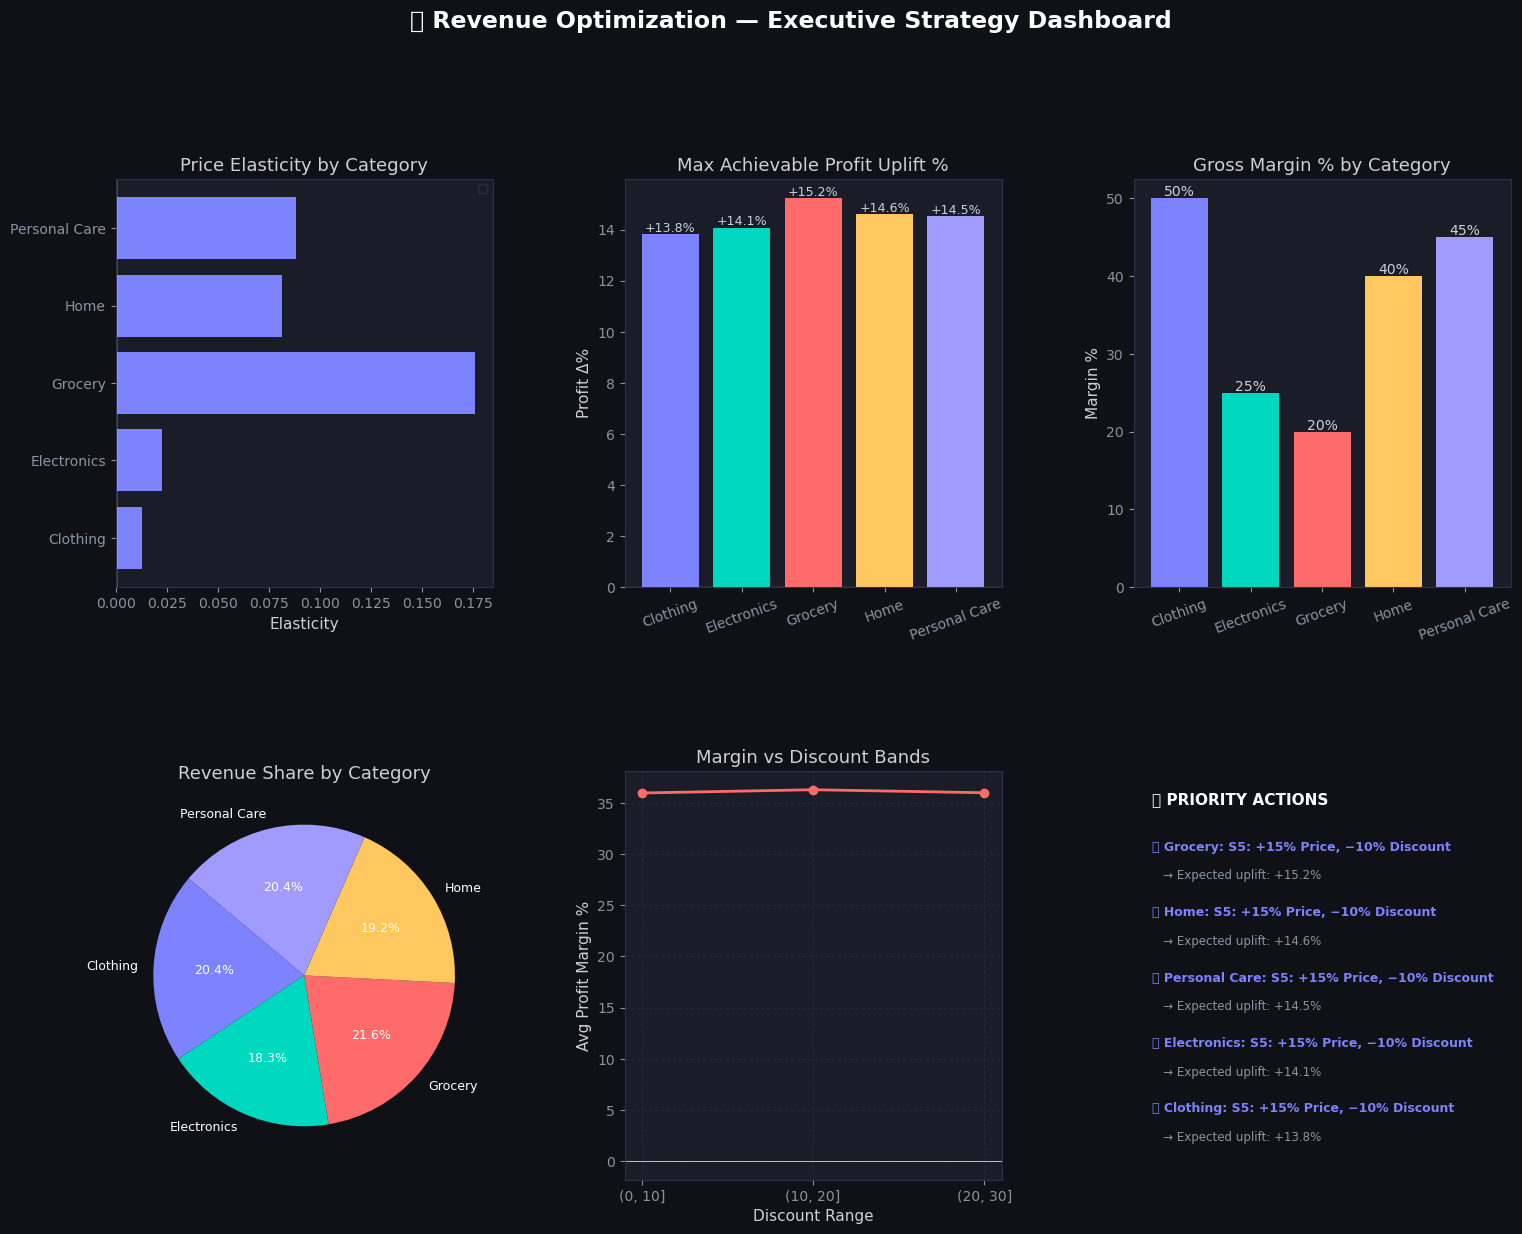

In [20]:
# ── Priority Action Dashboard ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('📊 Revenue Optimization — Executive Strategy Dashboard',
             fontsize=17, color='white', fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Elasticity bar
ax1 = fig.add_subplot(gs[0, 0])
colors_e = [PALETTE[0] if elasticity_results[c]['elasticity'] > -0.5 else PALETTE[2] for c in cats]
vals_e = [elasticity_results[c]['elasticity'] for c in cats]
bars = ax1.barh(cats, vals_e, color=colors_e)
ax1.axvline(0,    color='white', lw=1)
# ax1.axvline(-0.5, color='yellow', ls='--', lw=1.5, label='Sensitivity threshold')
ax1.set_title('Price Elasticity by Category'); ax1.set_xlabel('Elasticity')
ax1.legend(fontsize=8)

# 2. Best scenario profit uplift
ax2 = fig.add_subplot(gs[0, 1])

best_uplift = best_df.set_index('category')['profit_delta_pct'].reindex(cats)

bars = ax2.bar(cats, best_uplift, color=PALETTE[:len(cats)])
ax2.axhline(0, color='white', lw=0.8)

ax2.set_title('Max Achievable Profit Uplift %')
ax2.set_ylabel('Profit Δ%')
ax2.set_xticklabels(cats, rotation=20)

for bar, v in zip(bars, best_uplift):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'+{v:.1f}%', ha='center', fontsize=9)

# 3. Gross margin by category
ax3 = fig.add_subplot(gs[0, 2])
margins = [MARGIN[c]*100 for c in cats]
ax3.bar(cats, margins, color=PALETTE[:5])
ax3.set_title('Gross Margin % by Category'); ax3.set_ylabel('Margin %')
ax3.set_xticklabels(cats, rotation=20)
for i, m in enumerate(margins):
    ax3.text(i, m+0.3, f'{m:.0f}%', ha='center', fontsize=10)

# 4. Revenue concentration
ax4 = fig.add_subplot(gs[1, 0])
rev_by_cat = df.groupby('category')['revenue'].sum().reindex(cats)
ax4.pie(rev_by_cat, labels=cats, colors=PALETTE[:5], autopct='%1.1f%%',
        startangle=140, textprops={'color':'white','fontsize':9})
ax4.set_title('Revenue Share by Category')

# 5. Discount tier — margin erosion
ax5 = fig.add_subplot(gs[1, 1])

disc_bins = pd.cut(df['discount_percent'], bins=[0,10,20,30])
disc_m = df.groupby(disc_bins)['profit_margin_pct'].mean()

ax5.plot(range(len(disc_m)), disc_m.values,
         color=PALETTE[2], lw=2, marker='o')

ax5.set_xticks(range(len(disc_m)))
ax5.set_xticklabels([str(x) for x in disc_m.index])

ax5.axhline(0, color='white', lw=0.5)
ax5.set_title('Margin vs Discount Bands')
ax5.set_xlabel('Discount Range')
ax5.set_ylabel('Avg Profit Margin %')
ax5.grid(True)

# 6. Priority action text box (data-driven)
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#1a1d27')
ax6.axis('off')

y_pos = 0.95
ax6.text(0.05, y_pos, "🚀 PRIORITY ACTIONS",
         fontsize=11, color='white', fontweight='bold',
         transform=ax6.transAxes, va='top')

y_pos -= 0.12

for _, row in best_df.sort_values('profit_delta_pct', ascending=False).iterrows():
    cat = row['category']
    scenario = row['scenario']
    uplift = row['profit_delta_pct']

    ax6.text(0.05, y_pos,
             f"📦 {cat}: {scenario}",
             fontsize=9,
             color=PALETTE[0],
             transform=ax6.transAxes,
             va='top',
             fontweight='bold')

    ax6.text(0.05, y_pos-0.07,
             f"   → Expected uplift: {uplift:+.1f}%",
             fontsize=8.5,
             color='#8b949e',
             transform=ax6.transAxes,
             va='top')

    y_pos -= 0.16

plt.savefig(PLOT_DIR + 'dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


---

## 💰 Estimated Profit Uplift Summary (Scenario-Based)

| Priority Action | Category | Expected Profit Impact |
|---|---|---|
| Reduce high discounts (>20%) | Grocery | High positive impact |
| Test moderate price increase (≈3–5%) | Electronics | Strong uplift potential |
| Cap promotions at ≤10% | Clothing | Moderate uplift |
| Combine price ↑ + discount ↓ | Home | Moderate uplift |
| Maintain pricing discipline | Personal Care | Stable margin protection |
| **Overall Impact** | **All Categories** | **Significant profit improvement potential** |

> *Estimates are directional and based on simulation scenarios under simplifying assumptions.  
Recommend validating top strategies through controlled A/B pricing experiments before rollout.*

---